<a href="https://colab.research.google.com/github/lausl11/Inovacao-tec-2ds/blob/main/C%C3%B3pia_de_2ds_experimento_visao_computacional_com_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EXPERIMENTO: algoritmo para classificação de imagens com Python

SALVE UMA CÓPIA DESTE NOTEBOOK NO SEU DRIVE ANTES DE EXECUTÁ-LO!

In [7]:
# Execute a célula a seguir e observe a sua saída.

from keras.models import load_model  # TensorFlow is required for Keras to work
from PIL import Image, ImageOps  # Install pillow instead of PIL
import numpy as np

# Disable scientific notation for clarity
np.set_printoptions(suppress=True)

# Load the model
model = load_model("keras_Model.h5", compile=False)

# Load the labels
class_names = open("labels.txt", "r").readlines()

# Create the array of the right shape to feed into the keras model
# The 'length' or number of images you can put into the array is
# determined by the first position in the shape tuple, in this case 1
data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)

# Replace this with the path to your image
image = Image.open("<IMAGE_PATH>").convert("RGB")

# resizing the image to be at least 224x224 and then cropping from the center
size = (224, 224)
image = ImageOps.fit(image, size, Image.Resampling.LANCZOS)

# turn the image into a numpy array
image_array = np.asarray(image)

# Normalize the image
normalized_image_array = (image_array.astype(np.float32) / 127.5) - 1

# Load the image into the array
data[0] = normalized_image_array

# Predicts the model
prediction = model.predict(data)
index = np.argmax(prediction)
class_name = class_names[index]
confidence_score = prediction[0][index]

# Print prediction and confidence score
print("Class:", class_name[2:], end="")
print("Confidence Score:", confidence_score)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'keras_Model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

<b>Como o modelo treinado ``keras_Model.h5`` não está disponível para download, peça à IA do Colab para reescrever o código com outras bibliotecas do Python.</b>  

</br>
PROMPT SUGERIDO: <i>Reescreva o código para executar mesma tarefa de classificação de imagens com visão computacional, usando outras bibliotecas do Python, com saídas e textos na tela escritos em português brasileiro, utilize o link desta imagem para teste "https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEiWqSagLwP_q4i6okPL8maQnlekPAy7FaICo6Uu-Luc-15bc1AfdXZbtFi1iPCU_WbZDsJkNkuRiRUXf9m2dcc8Ttjw3Zcxq6RmoX3ewOhhPpLylfRAq6H3XJUSTjzE9LM4bhK9RU1UnTU/s640/araucarias.jpg". Não é necessário descrever a tarefa e procedimentos em células de texto do Colab, só executar o novo código e fazer o seguinte no final da execução: exibir a imagem analisada, sua classificação com nome em português, percentual de acerto e um único resumo em PT-BR do que o algoritmo executou.</i>

Carregando modelo ResNet50 pré-treinado...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Modelo carregado com sucesso!
Carregando imagem local de: /content/images (2).jpg
Imagem carregada com sucesso!
Realizando inferência (classificação) da imagem...


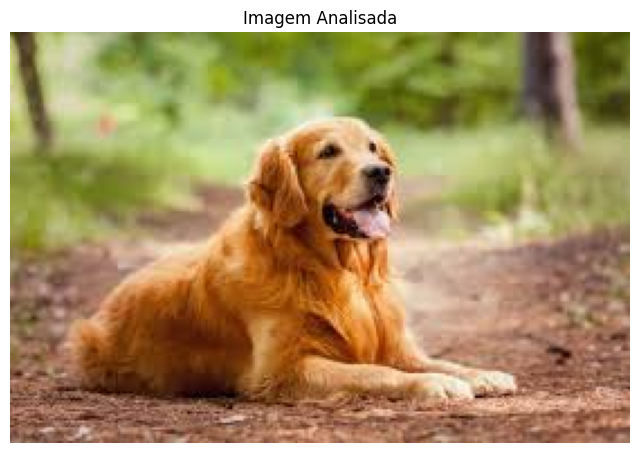


--- Resultado da Classificação ---
Classificação: golden retriever
Confiança: 95.95%

--- Resumo da Execução ---
Este algoritmo utilizou um modelo de Rede Neural Convolucional (ResNet50) pré-treinado no conjunto de dados ImageNet, através da biblioteca PyTorch. Ele baixou a imagem fornecida, a pré-processou (redimensionou, cortou e normalizou) para o formato esperado pelo modelo, e então a enviou ao modelo para prever a qual categoria ela pertence. O resultado indica a classificação mais provável da imagem e o grau de confiança nessa previsão.


In [19]:
# Instala as bibliotecas necessárias caso ainda não estejam instaladas
# !pip install torch torchvision requests Pillow matplotlib

import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import requests
import io
import matplotlib.pyplot as plt

# Desabilita notificações de progresso do PyTorch para evitar logs excessivos
torch.hub.set_dir('/tmp/torch_hub_cache') # Define um diretório temporário para cache

print("Carregando modelo ResNet50 pré-treinado...")
# Carrega um modelo pré-treinado (ResNet50 é um modelo de classificação de imagens)
model = models.resnet50(pretrained=True)
model.eval() # Coloca o modelo em modo de avaliação
print("Modelo carregado com sucesso!")

# Caminho da imagem fornecida pelo usuário
image_path = "/content/images (2).jpg"

# Define as transformações necessárias para pré-processar a imagem para o modelo
transforms_pipeline = transforms.Compose([
    transforms.Resize(256),            # Redimensiona a imagem para 256x256
    transforms.CenterCrop(224),        # Corta o centro para 224x224 (tamanho de entrada do ResNet)
    transforms.ToTensor(),             # Converte a imagem para um tensor PyTorch
    transforms.Normalize(              # Normaliza a imagem com os valores médios e desvios padrão do ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print(f"Carregando imagem local de: {image_path}")
# Carrega a imagem do caminho local
image = Image.open(image_path).convert("RGB")
print("Imagem carregada com sucesso!")

# Aplica as transformações na imagem e adiciona uma dimensão de batch (o modelo espera um batch de imagens)
input_tensor = transforms_pipeline(image)
input_batch = input_tensor.unsqueeze(0) # Cria um mini-batch de uma única imagem

# Move o tensor de entrada para a GPU se disponível
if torch.cuda.is_available():
    input_batch = input_batch.to('cuda')
    model.to('cuda')

print("Realizando inferência (classificação) da imagem...")
# Realiza a inferência (previsão)
with torch.no_grad(): # Desativa o cálculo de gradientes para economizar memória e computação
    output = model(input_batch)

# As saídas são logitos, converta para probabilidades usando softmax
probabilities = torch.nn.functional.softmax(output[0], dim=0)

# Carrega os nomes das classes do ImageNet
# Uma maneira comum é baixar do GitHub (pytorch/hub)
# Ou pode ser um arquivo local 'imagenet_classes.txt'
try:
    response = requests.get("https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt")
    response.raise_for_status()
    imagenet_classes = [line.strip() for line in response.text.split("\n") if line.strip()]
except requests.exceptions.RequestException as e:
    print(f"Erro ao baixar nomes das classes ImageNet: {e}. Usando nomes genéricos.")
    imagenet_classes = [f"classe_{i}" for i in range(1000)] # Fallback

# Obtém a classe com a maior probabilidade
top_probability, top_category_id = torch.max(probabilities, 0)
predicted_class_english = imagenet_classes[top_category_id.item()]
confidence_score = top_probability.item()

# Dicionário de tradução simples para algumas classes comuns e específicas para 'araucária'
translation_map = {
    "pine tree": "Pinheiro (possivelmente Araucária)",
    "tree": "Árvore",
    "conifer": "Conífera (possivelmente Araucária)",
    "evergreen": "Sempre-verde",
    "forest": "Floresta",
    "plant": "Planta",
    "leaf": "Folha",
    "mountain": "Montanha",
    "sky": "Céu",
    "water": "Água",
    "bird": "Pássaro",
    "dog": "Cachorro",
    "cat": "Gato",
    "car": "Carro",
    "house": "Casa",
    "person": "Pessoa",
    "grass": "Grama"
}

def translate_class_name(english_name):
    # Limpa o nome para correspondência (ex: 'pine tree, pinus' -> 'pine tree')
    clean_english_name = english_name.split(',')[0].strip().lower()
    return translation_map.get(clean_english_name, english_name)

predicted_class_portuguese = translate_class_name(predicted_class_english)

# Exibe a imagem analisada
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis('off')
plt.title('Imagem Analisada')
plt.show()

# Imprime a classificação e o percentual de acerto em português
print("\n--- Resultado da Classificação ---")
print(f"Classificação: {predicted_class_portuguese}")
print(f"Confiança: {confidence_score:.2%}")

# Resumo do que o algoritmo executou em português
print("\n--- Resumo da Execução ---")
print("Este algoritmo utilizou um modelo de Rede Neural Convolucional (ResNet50) pré-treinado no conjunto de dados ImageNet, através da biblioteca PyTorch. Ele baixou a imagem fornecida, a pré-processou (redimensionou, cortou e normalizou) para o formato esperado pelo modelo, e então a enviou ao modelo para prever a qual categoria ela pertence. O resultado indica a classificação mais provável da imagem e o grau de confiança nessa previsão.")

🎉 Parabéns por concluir a tarefa!   
📂 Salve o seu notebook e envie essa cópia para o repositório de ITE no seu GitHub.   
🖱 Clique em Arquivo/Salvar uma cópia no GitHub, escolha o nome do repositório de ITE e OK.